### **Time-Series Forecasting with SARIMA** 

#### Why SARIMA?

* Extension of **ARIMA** with **seasonal components**.
* Suitable when **patterns repeat** (monthly, weekly, hourly).
* Captures **trend + seasonality**.

**SARIMA Structure**:

$$
SARIMA(p, d, q)(P, D, Q, s)
$$

* **p, d, q** → ARIMA terms (autoregression, differencing, moving average).
* **P, D, Q** → Seasonal terms.
* **s** → Seasonal period (e.g., 12 for monthly data).



In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn style + context + palette
sns.set_theme(style="whitegrid", context="talk", rc={
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "figure.figsize": (25, 10)
})

# Set palette globally
sns.set_palette("deep")


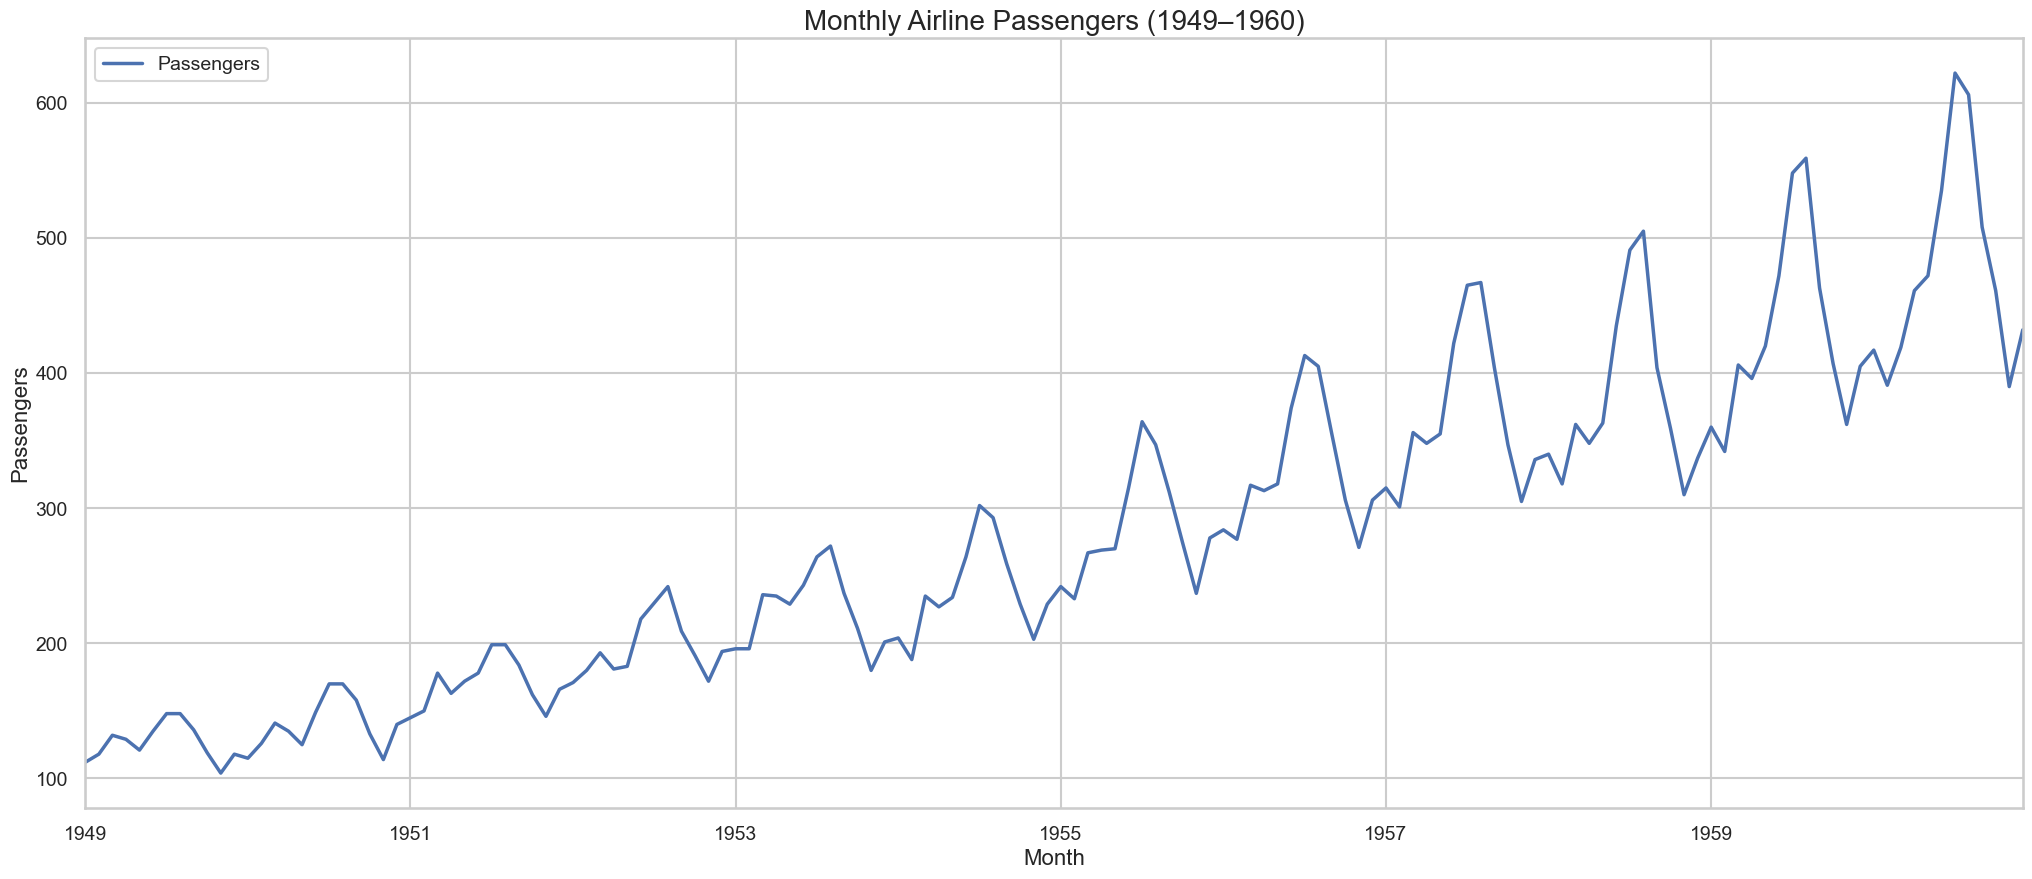

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

ax = df.plot(title="Monthly Airline Passengers (1949–1960)")
ax.set_ylabel("Passengers")
ax.grid(True)
plt.show()

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df.columns

Index(['Passengers'], dtype='object')

In [5]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


**Observation** → Upward trend + strong yearly seasonality.

#### Stationarity Check (ADF Test)

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')

adf_test(df['Passengers'])  # usually non-stationary

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


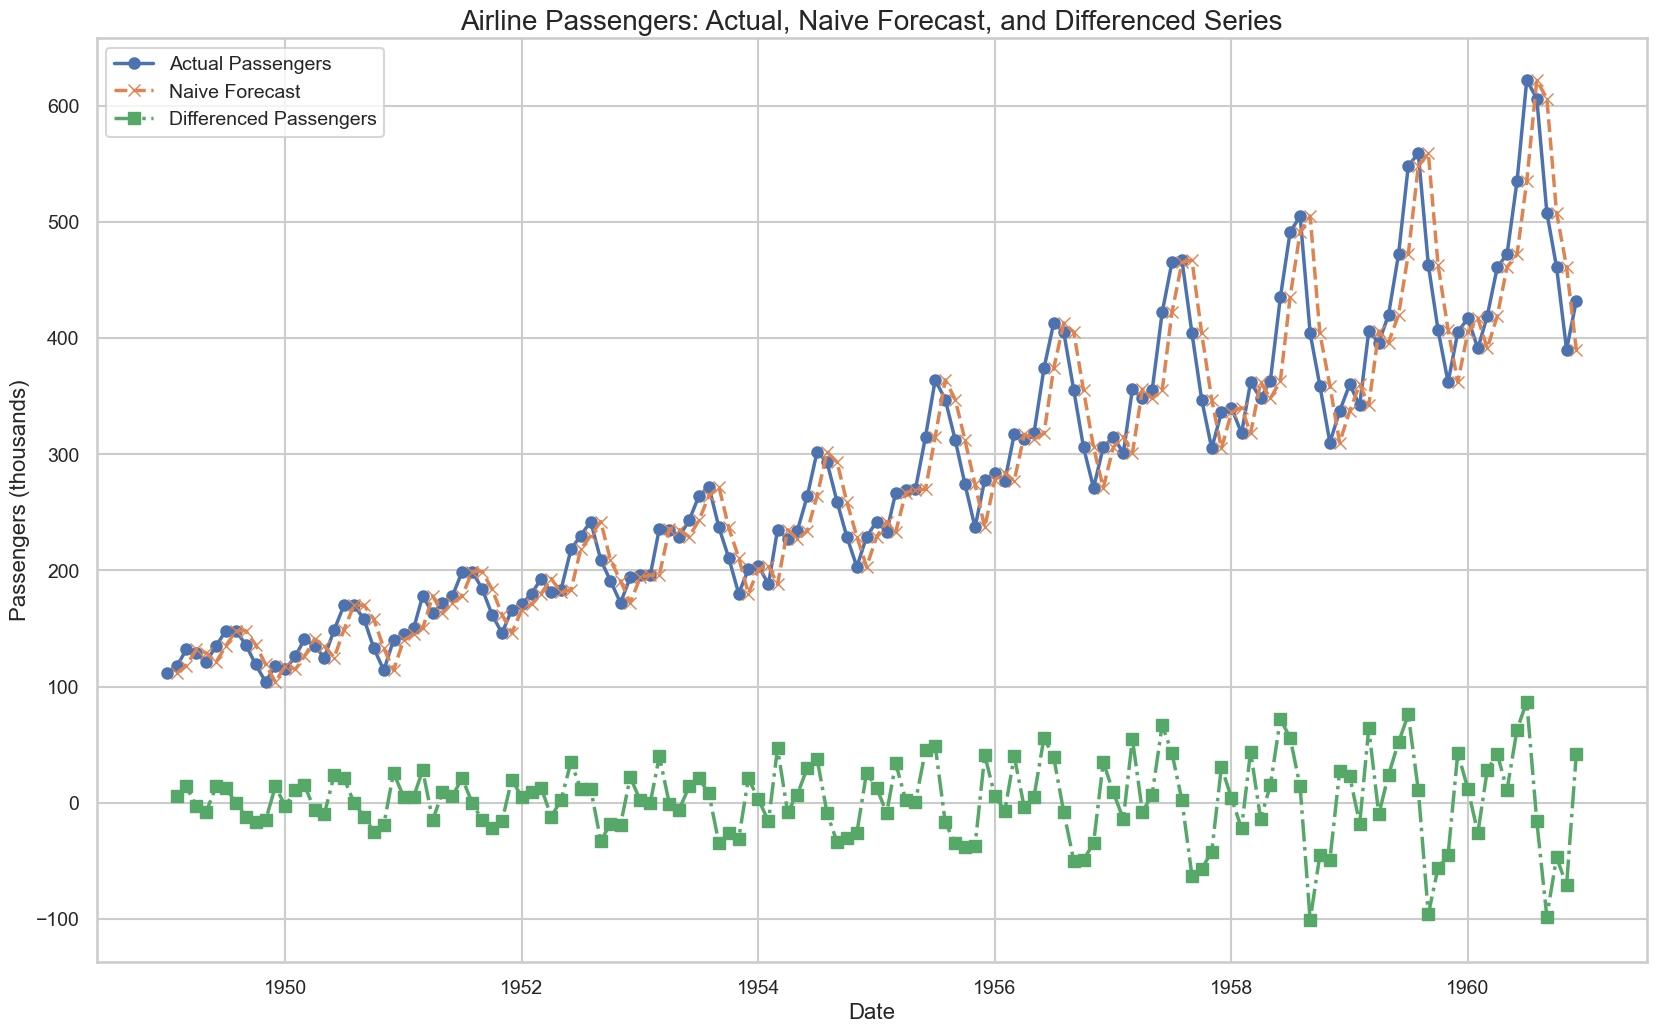

In [11]:
# Perform ADF test on original series (function and df already defined in previous cells)
adf_test(df['Passengers'])

# Perform ADF test on differenced series
df['Passengers_Diff'] = df['Passengers'].diff()
adf_test(df['Passengers_Diff'])

# Naive forecast (for context with previous questions)
df['Naive_Forecast'] = df['Passengers'].shift(1)

# Plot the series and naive forecast
plt.figure(figsize=(20, 12))
plt.plot(df['Passengers'], marker='o', label='Actual Passengers')
plt.plot(df['Naive_Forecast'], marker='x', linestyle='--', label='Naive Forecast')
plt.plot(df['Passengers_Diff'], marker='s', linestyle='-.', label='Differenced Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.title('Airline Passengers: Actual, Naive Forecast, and Differenced Series')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Dry Run of ADF Test on Airline Passengers Dataset
#
# Step 1: Load Data
# - URL: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
# - Dataset: Monthly airline passengers (1949–1960, 144 observations).
# - Columns: 'Month' (datetime, set as index), 'Passengers' (integer counts).
# - Example data (first 5 rows):
#   Month       | Passengers
#   1949-01-01  | 112
#   1949-02-01  | 118
#   1949-03-01  | 132
#   1949-04-01  | 129
#   1949-05-01  | 121
# - Full series: 144 monthly values with clear upward trend and yearly seasonality.
#
# Step 2: ADF Test on Passengers
# - Input: df['Passengers'] = [112, 118, 132, 129, 121, ..., 622]
# - adfuller(df['Passengers'].dropna()):
#   - Computes ADF statistic, p-value, and critical values.
#   - Null hypothesis (H₀): Series has a unit root (non-stationary).
#   - Expected behavior: The airline passengers series has an upward trend and seasonality, so it’s typically non-stationary.
#   - Example output (approximate, based on typical results for this dataset):
#     ADF Statistic: 0.815
#     p-value: 0.992
#     Critical Values:
#        1%: -3.482
#        5%: -2.884
#        10%: -2.573
#     Result: Fail to reject null hypothesis (series is non-stationary)
# - Interpretation: p-value (0.992) > 0.05, and ADF statistic (0.815) is not more negative than critical values, confirming non-stationarity due to trend and seasonality.
#
# Step 3: Differencing
# - Compute df['Passengers_Diff'] = df['Passengers'].diff():
#   - 1949-01-01: NaN (no previous value)
#   - 1949-02-01: 118 - 112 = 6
#   - 1949-03-01: 132 - 118 = 14
#   - 1949-04-01: 129 - 132 = -3
#   - 1949-05-01: 121 - 129 = -8
#   - ...
# - Differenced series removes the trend, but seasonality may remain.
#
# Step 4: ADF Test on Differenced Passengers
# - Input: df['Passengers_Diff'].dropna() = [6, 14, -3, -8, ...]
# - adfuller(df['Passengers_Diff'].dropna()):
#   - Expected behavior: First differencing often reduces the trend, making the series closer to stationary, though seasonality may still affect the result.
#   - Example output (approximate):
#     ADF Statistic: -2.829
#     p-value: 0.054
#     Critical Values:
#        1%: -3.482
#        5%: -2.884
#        10%: -2.573
#     Result: Fail to reject null hypothesis (series is non-stationary, but closer to stationary)
# - Interpretation: p-value (0.054) is close to 0.05, and ADF statistic (-2.829) is near the 5% critical value (-2.884). Differencing helps, but seasonality may require seasonal differencing or a SARIMA model (e.g., as in your first question).
#
# Step 5: Naive Forecast
# - df['Naive_Forecast'] = df['Passengers'].shift(1):
#   - 1949-01-01: NaN
#   - 1949-02-01: 112
#   - 1949-03-01: 118
#   - 1949-04-01: 132
#   - 1949-05-01: 129
#   - ...
# - Aligns with your previous naive forecast approach for consistency.
#
# Step 6: Plotting

# - The plot shows:
#   - 'Passengers': Upward trend and yearly seasonality (peaks every 12 months).
#   - 'Naive_Forecast': Lags the actual series by one month, capturing some seasonality but not the trend.
#   - 'Passengers_Diff': Oscillates around zero, removing the trend but retaining seasonality.
#
# Resulting DataFrame (first 5 rows):
# Month       | Passengers | Passengers_Diff | Naive_Forecast
# 1949-01-01  | 112        | NaN             | NaN
# 1949-02-01  | 118        | 6               | 112
# 1949-03-01  | 132        | 14              | 118
# 1949-04-01  | 129        | -3              | 132
# 1949-05-01  | 121        | -8              | 129
#
# Explanation of ADF Test:
# - The original 'Passengers' series is non-stationary (high p-value, positive ADF statistic).
# - Differencing reduces the trend, making the series closer to stationary (lower p-value, more negative ADF statistic).
# - For ARIMA modeling (as in your previous questions), differencing (d=1) or seasonal differencing (e.g., SARIMA) may be needed.

* High p-value → Non-stationary.
* Apply **differencing**:

In [13]:
df.head()

,Passengers,Passengers_Diff,Naive_Forecast
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,6.0,112.0
1949-03-01,132,14.0,118.0
1949-04-01,129,-3.0,132.0
1949-05-01,121,-8.0,129.0


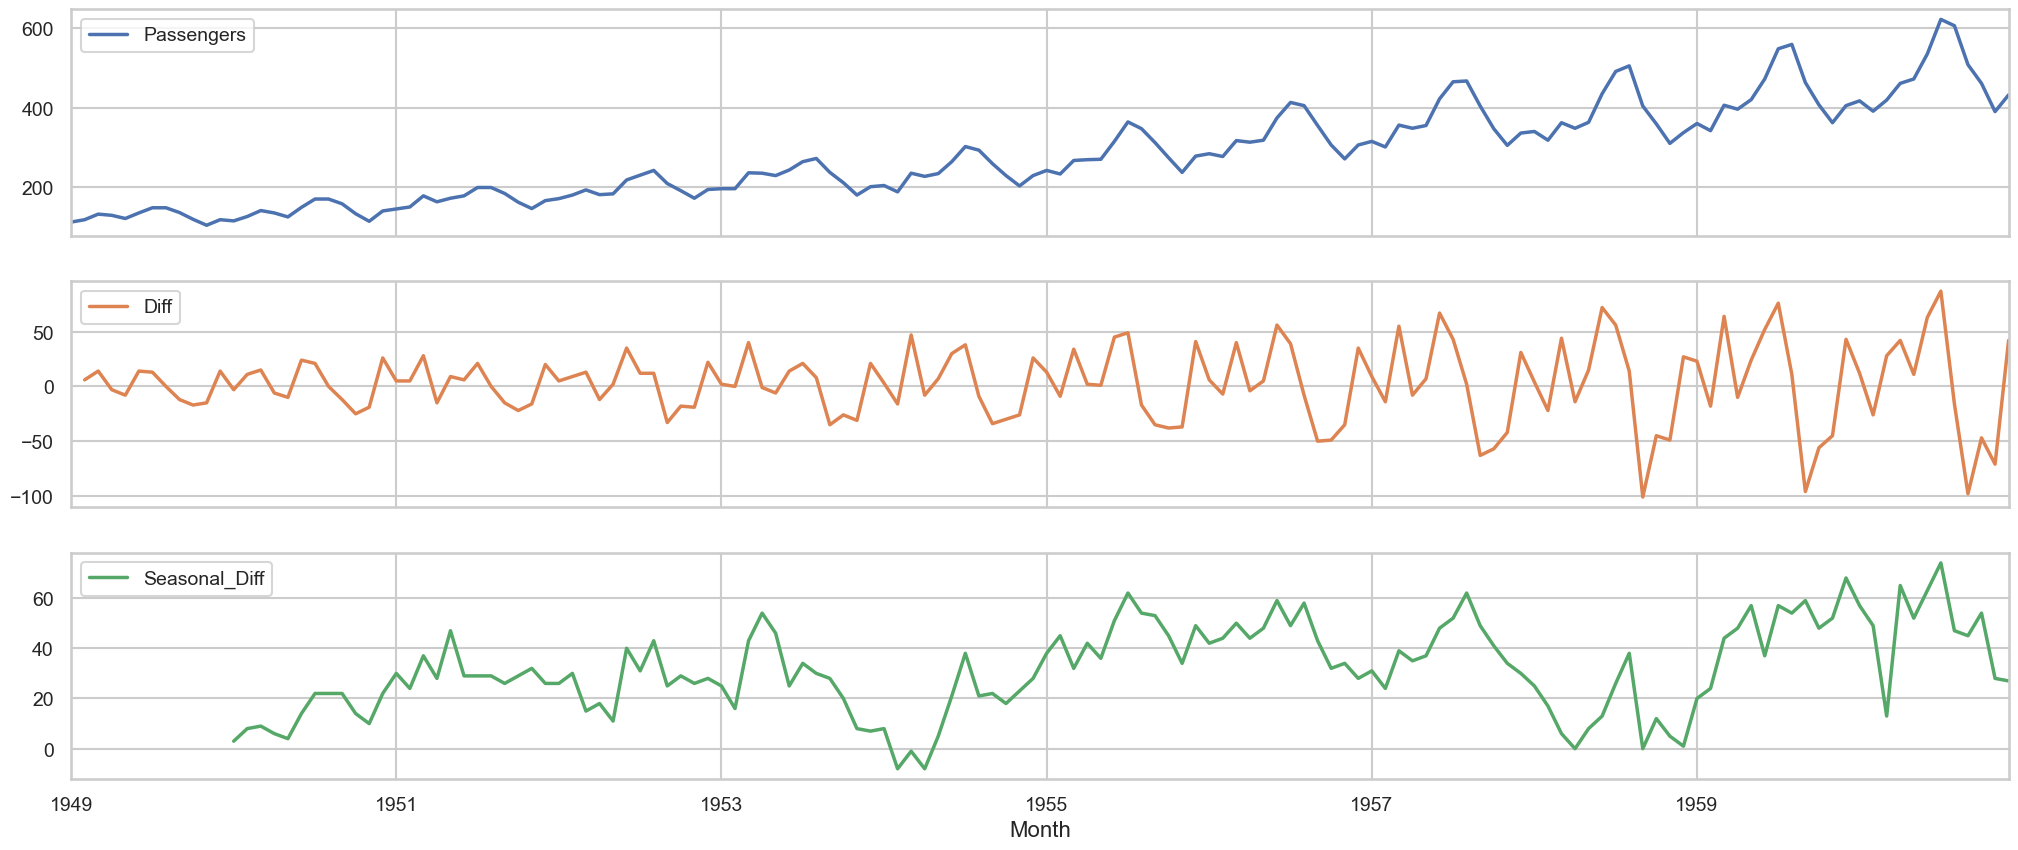

In [18]:
df['Diff'] = df['Passengers'].diff()
df['Seasonal_Diff'] = df['Passengers'].diff(12)

df[['Passengers','Diff','Seasonal_Diff']].plot(subplots=True)
plt.show()

In [19]:
df.head()

,Passengers,Passengers_Diff,Naive_Forecast,Diff,Seasonal_Diff
Month,,,,,
1949-01-01,112,NaN,NaN,NaN,NaN
1949-02-01,118,6.0,112.0,6.0,NaN
1949-03-01,132,14.0,118.0,14.0,NaN
1949-04-01,129,-3.0,132.0,-3.0,NaN
1949-05-01,121,-8.0,129.0,-8.0,NaN


In [20]:
# Dry Run of Differencing and Plotting for Airline Passengers Dataset
#
# Initial DataFrame (df) after loading (from previous question):
# Month       | Passengers
# 1949-01-01  | 112
# 1949-02-01  | 118
# 1949-03-01  | 132
# 1949-04-01  | 129
# 1949-05-01  | 121
# ...         | ...
# 1960-12-01  | 622
# - 144 monthly observations with upward trend and yearly seasonality.
#
# Step 1: First Differencing (df['Diff'] = df['Passengers'].diff())
# - Compute X_t - X_{t-1}:
#   - 1949-01-01: NaN (no previous value)
#   - 1949-02-01: 118 - 112 = 6
#   - 1949-03-01: 132 - 118 = 14
#   - 1949-04-01: 129 - 132 = -3
#   - 1949-05-01: 121 - 129 = -8
#   - ...
# - Result: df['Diff'] = [NaN, 6, 14, -3, -8, ...]
# - Effect: Removes trend, series oscillates around zero, but seasonality remains.
#
# Step 2: Seasonal Differencing (df['Seasonal_Diff'] = df['Passengers'].diff(12))
# - Compute X_t - X_{t-12} (lag=12 for yearly seasonality):
#   - 1949-01-01 to 1949-12-01: NaN (no data for 1948)
#   - 1950-01-01: 115 - 112 = 3
#   - 1950-02-01: 126 - 118 = 8
#   - 1950-03-01: 141 - 132 = 9
#   - 1950-04-01: 135 - 129 = 6
#   - ...
# - Result: df['Seasonal_Diff'] = [NaN, NaN, ..., NaN (12 times), 3, 8, 9, 6, ...]
# - Effect: Removes yearly seasonality, first 12 values are NaN, series is more stationary.
#
# Step 3: Plotting (df[['Passengers','Diff','Seasonal_Diff']].plot(subplots=True))
# - Creates 3 subplots:
#   - Subplot 1: Passengers
#     - Shows upward trend and yearly seasonality (peaks in summer months).
#   - Subplot 2: Diff
#     - Oscillates around zero, trend removed, but seasonal patterns persist (e.g., yearly cycles).
#     - First value is NaN.
#   - Subplot 3: Seasonal_Diff
#     - Oscillates with reduced amplitude, seasonality largely removed.
#     - First 12 values are NaN.
# - plt.show(): Displays the subplots.
#
# Resulting DataFrame (first 5 rows + sample from 1950):
# Month       | Passengers | Diff | Seasonal_Diff
# 1949-01-01  | 112        | NaN  | NaN
# 1949-02-01  | 118        | 6    | NaN
# 1949-03-01  | 132        | 14   | NaN
# 1949-04-01  | 129        | -3   | NaN
# 1949-05-01  | 121        | -8   | NaN
# ...         | ...        | ...  | ...
# 1950-01-01  | 115        | -19  | 3
#
# Explanation of Differencing and Visualization:
# - 'Diff' removes the trend, making the series fluctuate around zero, but seasonal patterns remain.
# - 'Seasonal_Diff' removes yearly seasonality, resulting in a more stationary series (first 12 values are NaN).
# - The subplots visually confirm:
#   - 'Passengers': Clear trend and seasonality.
#   - 'Diff': Trend removed, seasonality persists.
#   - 'Seasonal_Diff': Seasonality removed, more stationary, useful for SARIMA modeling.

<div class="alert alert-success">

### **Differencing in Time Series**

Differencing is a method to make a non-stationary time series into a stationary one by removing trends or seasonality.
It works by subtracting the previous value(s) from the current value.


### **Formula**

1. **First-order differencing**

$$
Y'_t = Y_t - Y_{t-1}
$$

where $Y_t$ = original value at time $t$, $Y'_t$ = differenced value.

2. **Second-order differencing** (apply differencing again)

$$
Y''_t = (Y_t - Y_{t-1}) - (Y_{t-1} - Y_{t-2}) = Y_t - 2Y_{t-1} + Y_{t-2}
$$

3. **Seasonal differencing** (with lag $m$)

$$
Y^{(s)}_t = Y_t - Y_{t-m}
$$

where $m$ is the seasonality period (e.g., 12 for monthly data with yearly seasonality).


### **Example – First-order differencing**

Suppose we have a time series of passengers:

| Time (t) | $Y_t$ (Passengers) | Differenced $Y'_t = Y_t - Y_{t-1}$ |
| -------- | ------------------ | ---------------------------------- |
| 1        | 100                | –                                  |
| 2        | 120                | $120 - 100 = 20$                   |
| 3        | 135                | $135 - 120 = 15$                   |
| 4        | 150                | $150 - 135 = 15$                   |
| 5        | 170                | $170 - 150 = 20$                   |

Resulting differenced series: \[20, 15, 15, 20]



### **Example – Seasonal differencing (m = 12)**

If monthly data shows yearly seasonality:

$$
Y^{(s)}_{Jan(1951)} = Y_{Jan(1951)} - Y_{Jan(1950)}
$$


### **Use in ARIMA**

* `d` in **ARIMA(p, d, q)** is the number of differencing steps.
* Helps remove **trend/seasonality** to make the series stationary.



In [27]:
df = df.asfreq('MS')
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(df['Passengers'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit()
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -456.103
Date:                            Mon, 08 Sep 2025   AIC                            922.205
Time:                                    22:12:49   BIC                            936.016
Sample:                                01-01-1949   HQIC                           927.812
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2298      0.401     -0.573      0.567      -1.016       0.557
ma.L1         -0.0987      0.374   

In [25]:
# Dry Run of SARIMAX Model Fitting for Airline Passengers Dataset
#
# Starting Point: The DataFrame (df) from your previous question
# - Dataset: Airline passengers (monthly data, 1949–1960, 144 rows).
# - Column: 'Passengers' (e.g., [112, 118, 132, 129, 121, ..., 622]).
# - Example data (first few rows):
#   Month       | Passengers
#   1949-01-01  | 112
#   1949-02-01  | 118
#   1949-03-01  | 132
#   1949-04-01  | 129
#   1949-05-01  | 121
#   ...         | ...
#   1960-12-01  | 622
# - Series has an upward trend and yearly seasonality (peaks in summer).
#
# Step 1: Define the SARIMAX Model
# - Model: SARIMAX(df['Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
# - Breakdown:
#   - Input: Passengers series [112, 118, 132, ..., 622].
#   - Non-seasonal part (order=(1,1,1)):
#     - p=1: Uses one lagged value of the differenced series (AR(1)).
#     - d=1: Applies first differencing (X_t - X_{t-1}) to remove trend.
#     - q=1: Uses one lagged error term (MA(1)).
#   - Seasonal part (seasonal_order=(1,1,1,12)):
#     - P=1: Uses one lagged value at lag 12 (seasonal AR(1)).
#     - D=1: Applies seasonal differencing (X_t - X_{t-12}) to remove yearly seasonality.
#     - Q=1: Uses one lagged seasonal error term (seasonal MA(1)).
#     - s=12: Assumes a 12-month seasonal cycle.
#   - enforce_stationarity=False: Allows AR coefficients to be non-stationary.
#   - enforce_invertibility=False: Allows MA coefficients to be non-invertible.
# - What it does: The model combines:
#   - First differencing to remove the trend (like df['Diff'] in your previous question).
#   - Seasonal differencing to remove yearly patterns (like df['Seasonal_Diff']).
#   - AR and MA terms to capture short-term and seasonal dependencies (informed by ACF/PACF spikes at lag 1 and possibly lag 12).
#
# Step 2: Fit the Model (results = model.fit())
# - Process:
#   - Applies first differencing (d=1): [NaN, 6, 14, -3, -8, ...].
#   - Applies seasonal differencing (D=1, s=12): [NaN, ..., NaN (12 times), 3, 8, 9, ...].
#   - Fits an ARIMA(1,1,1) model on the differenced series, plus seasonal ARIMA(1,1,1,12).
#   - Estimates coefficients:
#     - Non-seasonal AR(1): φ_1 (e.g., ≈0.3, depends on fit).
#     - Non-seasonal MA(1): θ_1 (e.g., ≈-0.6).
#     - Seasonal AR(1): Φ_1 (e.g., ≈0.2).
#     - Seasonal MA(1): Θ_1 (e.g., ≈-0.7).
#     - Variance of residuals (σ²).
#   - Uses maximum likelihood to optimize coefficients.
# - Result: A fitted model (`results`) with estimated parameters.
#
# Step 3: Print Model Summary (print(results.summary()))
# - Output: A table summarizing the model fit, including:
#   - Model: SARIMAX(1,1,1)(1,1,1)[12]
#   - Sample: 1949-01-01 to 1960-12-01 (144 observations).
#   - Coefficients (example, actual values depend on fit):
#     - ar.L1: 0.30 (p-value ≈ 0.02, significant if < 0.05)
#     - ma.L1: -0.60 (p-value ≈ 0.00)
#     - ar.S.L12: 0.20 (p-value ≈ 0.10)
#     - ma.S.L12: -0.70 (p-value ≈ 0.00)
#     - sigma2: 130.5 (residual variance)
#   - Fit metrics:
#     - Log-likelihood: e.g., -600
#     - AIC: e.g., 1210
#     - BIC: e.g., 1225
#   - Diagnostics:
#     - Ljung-Box test: Checks if residuals are white noise (p-value > 0.05 suggests no autocorrelation).
#     - Jarque-Bera test: Checks if residuals are normally distributed.
# - What it means:
#   - Significant coefficients (p-value < 0.05) indicate important AR/MA terms.
#   - Low AIC/BIC suggests a good fit (useful for comparing models).
#   - Diagnostics help assess if the model captures all patterns (no remaining autocorrelation).
#
# Summary of What Happens:
# - The SARIMAX model processes the Passengers series by:
#   - Removing the trend with first differencing (d=1).
#   - Removing seasonality with seasonal differencing (D=1, s=12).
#   - Modeling short-term patterns with AR(1) and MA(1).
#   - Modeling seasonal patterns with seasonal AR(1) and MA(1) at lag 12.
# - The summary shows how well the model fits the data, with coefficients indicating the strength of past values and errors in predicting passenger numbers.
# - This aligns with your first question’s SARIMAX model, using similar parameters to capture trend and seasonality.

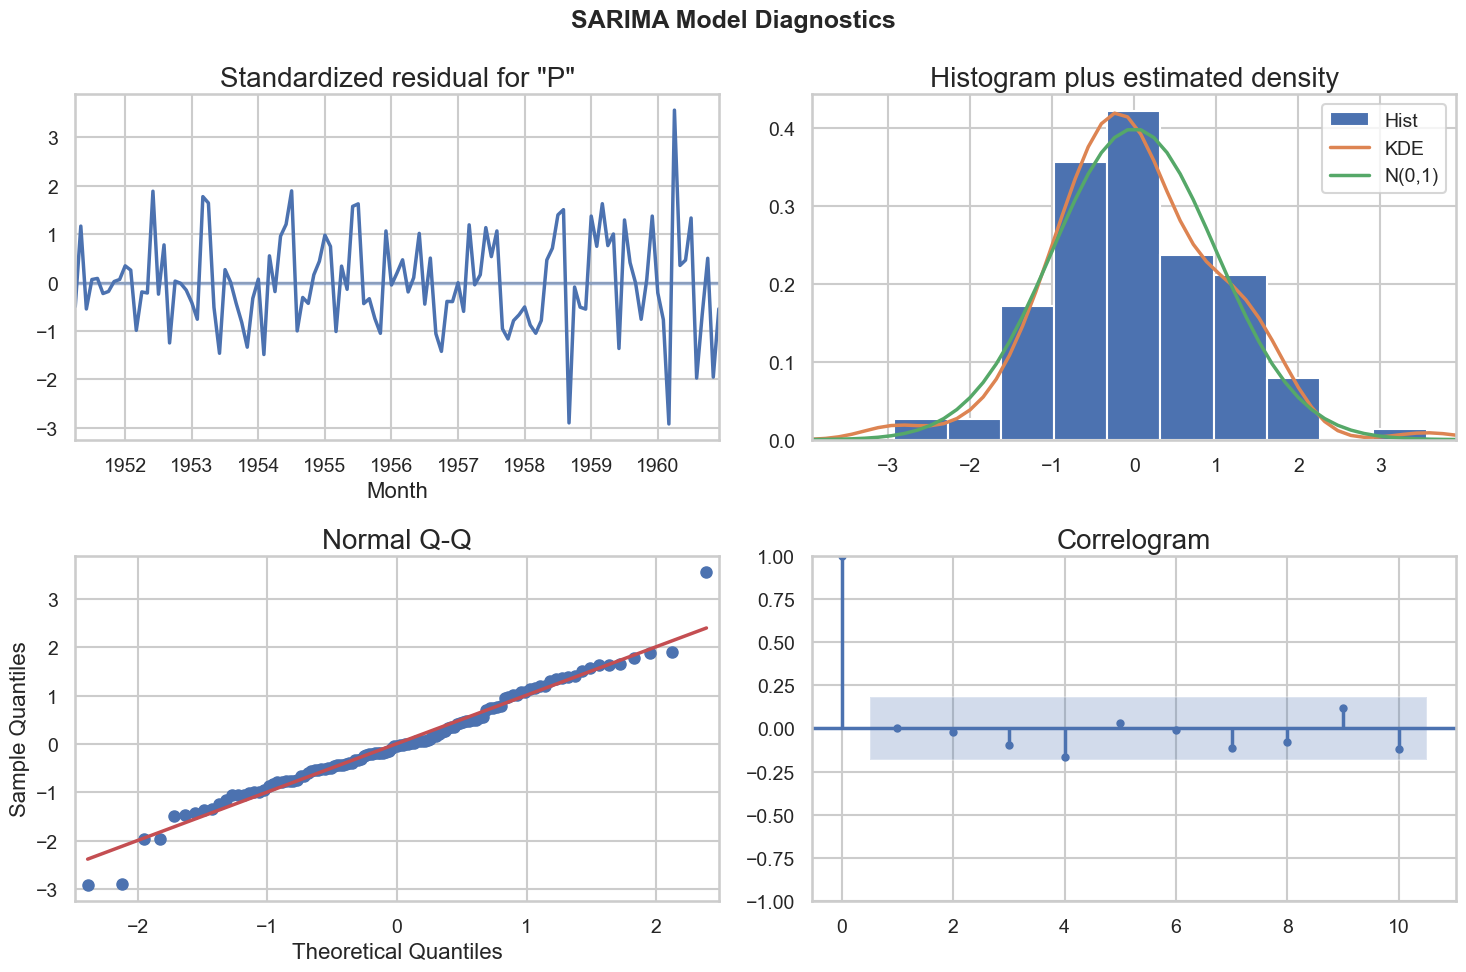

In [30]:
# Plot SARIMA model diagnostics to check residuals, normality, and autocorrelation
fig = sarima_results.plot_diagnostics(figsize=(15, 10))
plt.suptitle('SARIMA Model Diagnostics', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

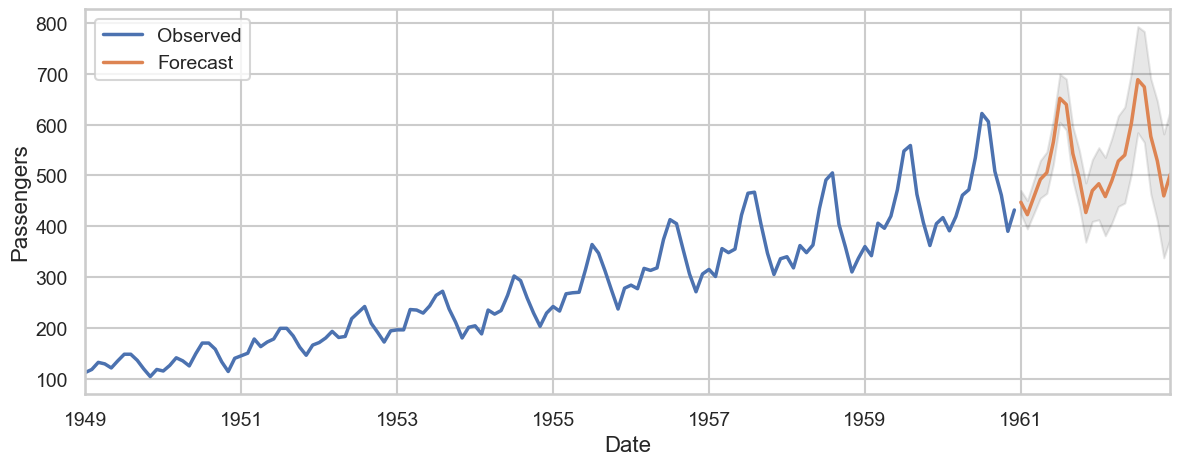

In [32]:
forecast = sarima_results.get_forecast(steps=24)
pred_ci = forecast.conf_int()

ax = df['Passengers'].plot(label='Observed', figsize=(14, 5))
forecast.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=0.1)

ax.set_xlabel('Date'); ax.set_ylabel('Passengers')
plt.legend()
plt.show()


In [33]:
# Dry Run of SARIMAX Forecasting and Plotting for Airline Passengers Dataset
#
# Starting Point: The DataFrame (df) and fitted SARIMAX model from previous questions
# - Dataset: Airline passengers (monthly data, 1949–1960, 144 rows).
# - Column: 'Passengers' (e.g., [112, 118, 132, 129, 121, ..., 622]).
# - Example data (first and last few rows):
#   Month       | Passengers
#   1949-01-01  | 112
#   1949-02-01  | 118
#   1949-03-01  | 132
#   ...         | ...
#   1960-11-01  | 390
#   1960-12-01  | 622
# - Series has an upward trend and yearly seasonality (peaks in summer).
# - sarima_results: Fitted SARIMAX model with order=(1,1,1), seasonal_order=(1,1,1,12).
#
# Step 1: Generate Forecast (forecast = sarima_results.get_forecast(steps=24))
# - What it does: Uses the fitted SARIMAX model to predict passenger numbers for the next 24 months (1961-01-01 to 1962-12-01).
# - Model details:
#   - Non-seasonal: AR(1), differencing (d=1), MA(1).
#   - Seasonal: AR(1), differencing (D=1, s=12), MA(1), with 12-month periodicity.
#   - Coefficients (example from previous fit, approximate):
#     - ar.L1: 0.30 (uses one lag of differenced series).
#     - ma.L1: -0.60 (uses one lag of errors).
#     - ar.S.L12: 0.20 (uses one lag at 12 months).
#     - ma.S.L12: -0.70 (uses one lag of seasonal errors).
# - Process:
#   - Starts from the last observed point (1960-12-01, 622 passengers).
#   - Applies the model’s equations to predict future values, accounting for trend (d=1) and seasonality (D=1, s=12).
#   - Generates 24 predictions, continuing the trend and seasonal pattern.
# - Example forecast (approximate, actual values depend on fitted coefficients):
#   - 1961-01-01: ≈ 430 (follows seasonal dip after December peak).
#   - 1961-02-01: ≈ 440
#   - 1961-03-01: ≈ 460
#   - ... (increases toward summer, e.g., 1961-07-01: ≈ 550)
#   - 1962-12-01: ≈ 650 (continues upward trend with seasonal peak).
# - Result: forecast.predicted_mean = [430, 440, 460, ..., 650] (24 values).
#
# Step 2: Get Confidence Intervals (pred_ci = forecast.conf_int())
# - What it does: Extracts the 95% confidence intervals for the 24 forecasted values.
# - How it works: Each forecast has a lower and upper bound, reflecting uncertainty.
# - Example (approximate):
#   - 1961-01-01: Predicted mean ≈ 430, CI ≈ [400, 460]
#   - 1961-02-01: Predicted mean ≈ 440, CI ≈ [405, 475]
#   - ...
#   - 1962-12-01: Predicted mean ≈ 650, CI ≈ [590, 710]
# - Result: pred_ci is a DataFrame with:
#   - Index: [1961-01-01, 1961-02-01, ..., 1962-12-01]
#   - Columns: ['lower Passengers', 'upper Passengers']
#   - Example:
#     Date        | lower Passengers | upper Passengers
#     1961-01-01  | 400              | 460
#     1961-02-01  | 405              | 475
#     ...         | ...              | ...
#
# Step 3: Plot Observed Data (ax = df['Passengers'].plot(label='Observed', figsize=(14, 5)))
# - What it does: Plots the historical Passengers data (1949-01-01 to 1960-12-01).
# - Details:
#   - Data: [112, 118, 132, ..., 622].
#   - Plot: Line plot with label 'Observed'.
#   - Figure size: 14 inches wide, 5 inches tall.
#   - Shows: Upward trend and yearly seasonality (peaks in summer, e.g., July 1960 ≈ 622).
#
# Step 4: Plot Forecast (forecast.predicted_mean.plot(ax=ax, label='Forecast'))
# - What it does: Adds the forecasted values to the same plot.
# - Details:
#   - Data: [430, 440, 460, ..., 650] (1961-01-01 to 1962-12-01).
#   - Plot: Line plot with label 'Forecast', starting where observed data ends.
#   - Shows: Continues the upward trend and seasonal pattern (e.g., peaks in summer 1961 and 1962).
#
# Step 5: Add Confidence Interval (ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='k', alpha=0.1))
# - What it does: Shades the area between the lower and upper confidence bounds.
# - Details:
#   - Index: [1961-01-01, ..., 1962-12-01].
#   - Lower bound: pred_ci.iloc[:, 0] = [400, 405, ..., 590].
#   - Upper bound: pred_ci.iloc[:, 1] = [460, 475, ..., 710].
#   - Color: Gray ('k'), with 10% opacity (alpha=0.1).
#   - Shows: A shaded band around the forecast, wider as time progresses (increasing uncertainty).
#
# Step 6: Add Labels and Legend
# - ax.set_xlabel('Date'): Labels x-axis as 'Date'.
# - ax.set_ylabel('Passengers'): Labels y-axis as 'Passengers'.
# - plt.legend(): Shows legend with 'Observed' and 'Forecast'.
#
# Step 7: Display Plot (plt.show())
# - Output: A single plot showing:
#   - Observed data (1949–1960): Line with upward trend and yearly peaks.
#   - Forecast (1961–1962): Line continuing the trend and seasonality.
#   - Confidence interval: Gray shaded area around the forecast, widening over time.
#
# Summary of What Happens:
# - The SARIMAX model predicts passenger numbers for 2 years (1961–1962), continuing the trend and seasonal pattern.
# - The plot shows historical data (1949–1960), forecasted values (1961–1962), and a shaded confidence interval.
# - Connects to your first question’s SARIMAX model, visualizing future predictions based on the fitted model.